# RNN for Next Word Prediction

Objective: To understand how a Recurrent Neural Network (RNN) can be used to predict the next word in a sentence based on previous words.

Import libraries

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import matplotlib.pyplot as plt

Load the Dataset

In [ ]:
# Load dataset
path = tf.keras.utils.get_file("shakespeare.txt","https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt")
text = open(path).read().lower()[:200000]  # use first 200k chars

Tokenization

In [ ]:
# Tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1
total_words

4900

Create sequences

In [ ]:
# Create input sequences
input_sequences = []
for line in text.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])

In [ ]:
token_list

[4899]

In [ ]:
input_sequences

[[39, 82],
 [113, 25],
 [113, 25, 557],
 [113, 25, 557, 193],
 [113, 25, 557, 193, 275],
 [113, 25, 557, 193, 275, 99],
 [113, 25, 557, 193, 275, 99, 23],
 [113, 25, 557, 193, 275, 99, 23, 100],
 [100, 100],
 [39, 82],
 [4, 28],
 [4, 28, 32],
 [4, 28, 32, 717],
 [4, 28, 32, 717, 196],
 [4, 28, 32, 717, 196, 3],
 [4, 28, 32, 717, 196, 3, 276],
 [4, 28, 32, 717, 196, 3, 276, 47],
 [4, 28, 32, 717, 196, 3, 276, 47, 3],
 [4, 28, 32, 717, 196, 3, 276, 47, 3, 1406],
 [717, 717],
 [39, 82],
 [39, 4],
 [39, 4, 94],
 [39, 4, 94, 277],
 [39, 4, 94, 277, 48],
 [39, 4, 94, 277, 48, 20],
 [39, 4, 94, 277, 48, 20, 1407],
 [39, 4, 94, 277, 48, 20, 1407, 298],
 [39, 4, 94, 277, 48, 20, 1407, 298, 3],
 [39, 4, 94, 277, 48, 20, 1407, 298, 3, 1],
 [39, 4, 94, 277, 48, 20, 1407, 298, 3, 1, 87],
 [25, 1054],
 [25, 1054, 25],
 [25, 1054, 25, 1054],
 [39, 82],
 [73, 55],
 [73, 55, 299],
 [73, 55, 299, 19],
 [73, 55, 299, 19, 2],
 [73, 55, 299, 19, 2, 313],
 [73, 55, 299, 19, 2, 313, 14],
 [73, 55, 299, 19, 2

Padding & labels

In [ ]:
# Padding
max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')
print("Total number of input sequences:", len(input_sequences))
print("\nMaximum length of the input sequences:", max_len)
input_sequences

Total number of input sequences: 29966

Maximum length of the input sequences: 13


array([[   0,    0,    0, ...,    0,   39,   82],
       [   0,    0,    0, ...,    0,  113,   25],
       [   0,    0,    0, ...,  113,   25,  557],
       ...,
       [   0,    0,    0, ...,   17,    9,   31],
       [   0,    0,    0, ...,    9,   31,  362],
       [   0,    0,    0, ...,   31,  362, 1369]], dtype=int32)

In [ ]:
X = input_sequences[:, :-1]
y = tf.keras.utils.to_categorical(input_sequences[:, -1], num_classes=total_words)

print(f"Total sequences: {len(input_sequences)}, Vocabulary size: {total_words}")
X.shape, y.shape

Total sequences: 29966, Vocabulary size: 4900


((29966, 12), (29966, 4900))

Build and Train RNN Model

In [ ]:
# Build model
model = Sequential()
model.add(Embedding(total_words, 100, input_length=max_len-1))
model.add(SimpleRNN(128))
model.add(Dense(total_words, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train model
history = model.fit(X, y, epochs=50, batch_size=128, validation_split=0.1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 25s 94ms/step - accuracy: 0.0273 - loss: 7.2150 - val_accuracy: 0.0404 - val_loss: 6.9250
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.0423 - loss: 6.4590 - val_accuracy: 0.0494 - val_loss: 6.9090
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.0537 - loss: 6.1979 - val_accuracy: 0.0557 - val_loss: 6.8719
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.0707 - loss: 5.8928 - val_accuracy: 0.0621 - val_loss: 6.8309
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.0872 - loss: 5.6301 - val_accuracy: 0.0727 - val_loss: 6.8525
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.1037 - loss: 5.3781 - val_accuracy: 0.0707 - val_loss: 6.9135
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.1164 - loss: 5.1483 - val_accuracy: 0.0721 - val_loss: 6.9869
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.1299 - loss: 4.9168 - v

Training Loss & Accuracy Plot

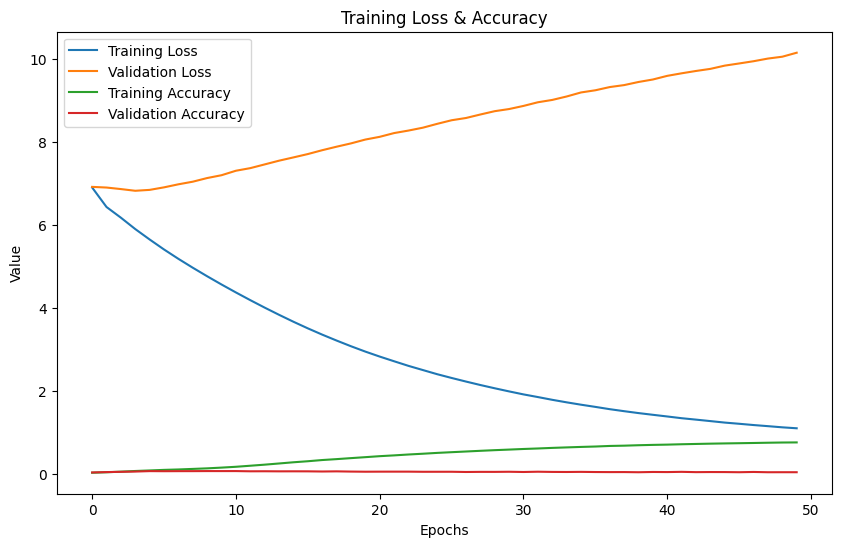

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training Loss & Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.legend()
plt.show()


Word Embedding PCA Visualization

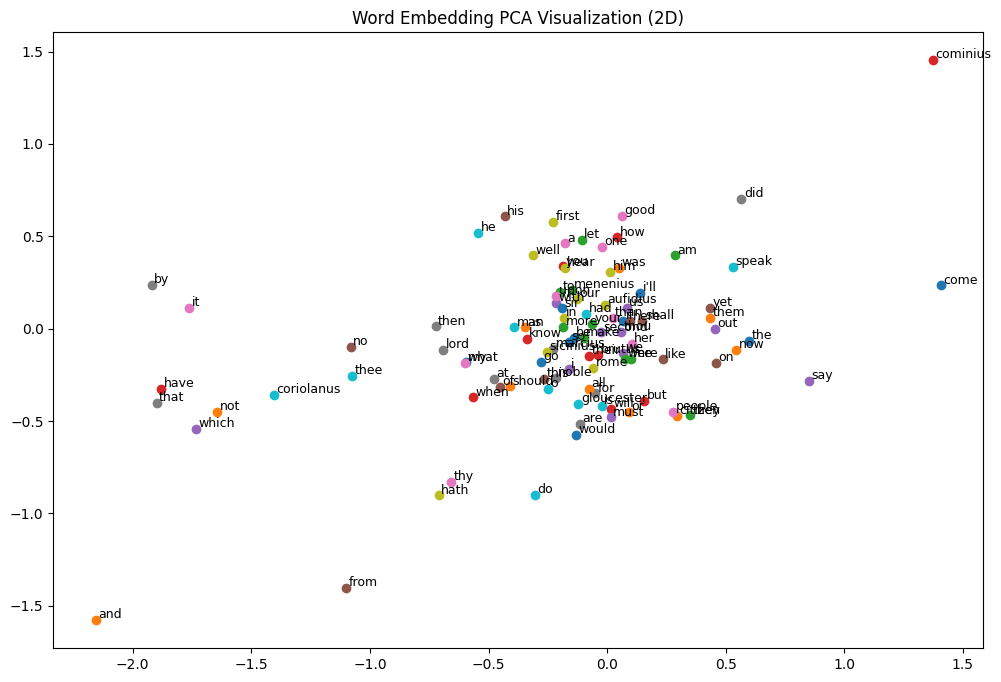

In [ ]:
from sklearn.decomposition import PCA

# Extract embeddings
embeddings = model.layers[0].get_weights()[0]  # Embedding layer weights

# Reduce dimensions
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Plot first 100 words
plt.figure(figsize=(12,8))
for i, word in enumerate(list(tokenizer.word_index.keys())[:100]):
    xnew, ynew = embeddings_2d[i]
    plt.scatter(xnew, ynew)
    plt.text(xnew+0.01, ynew+0.01, word, fontsize=9)
plt.title("Word Embedding PCA Visualization (2D)")
plt.show()


Next-Word Prediction Function

In [ ]:
def predict_next_word(seed_text, n_words=5):
    result = seed_text
    for _ in range(n_words):
        seq = tokenizer.texts_to_sequences([result])[0]
        seq = pad_sequences([seq], maxlen=max_len-1, padding='pre')
        pred_probs = model.predict(seq, verbose=0)[0]
        pred_index = np.argmax(pred_probs)

        # Map index back to word
        for word, index in tokenizer.word_index.items():
            if index == pred_index:
                result += " " + word
                break
    return result

Test Prediction

In [ ]:
# Example
seed = "this is a noble of the"
print(predict_next_word(seed, 5))

this is a noble of the wars and safely home was


Next-Word Prediction Probability Bar Chart

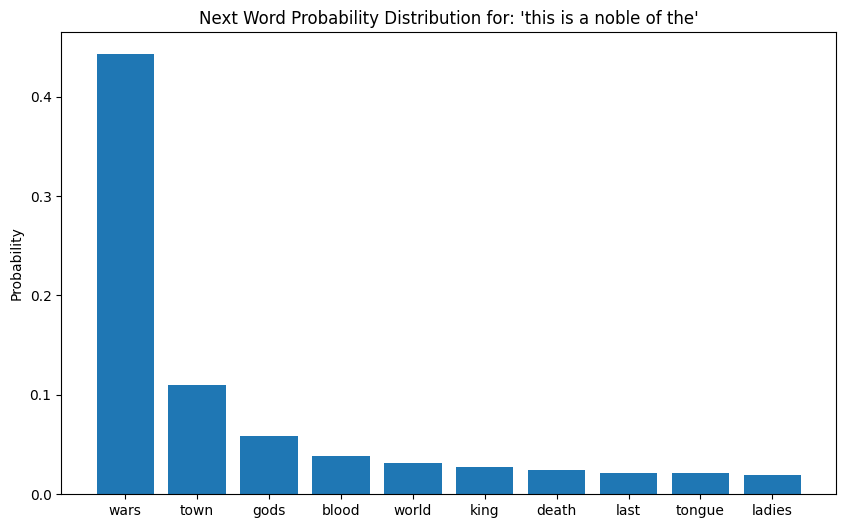

In [ ]:
seed_text = "this is a noble of the"
seq = tokenizer.texts_to_sequences([seed_text])[0]
seq = pad_sequences([seq], maxlen=max_len-1, padding='pre')
pred_probs = model.predict(seq, verbose=0)[0]

# Top 10 predicted words
top_indices = pred_probs.argsort()[-10:][::-1]
top_words = [tokenizer.index_word[i] for i in top_indices]
top_probs = [pred_probs[i] for i in top_indices]

plt.figure(figsize=(10,6))
plt.bar(top_words, top_probs)
plt.title(f"Next Word Probability Distribution for: '{seed_text}'")
plt.ylabel("Probability")
plt.show()
